In [7]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc, w_object, patch_creation
modify_rc()
modify_rc()
from src import synthesize


In [2]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)

sky6 = sm.Sky(nside=NSIDE, preset_strings=['s6'])

cl_tt = sky6.components[0].small_scale_cl[0][:LMAX+1].value
cl_tt[cl_tt == 0.] = 1e-15
cl_ee = sky6.components[0].small_scale_cl[1][:LMAX+1].value
cl_ee[cl_ee == 0.] = 1e-15
cl_bb = sky6.components[0].small_scale_cl[2][:LMAX+1].value
cl_bb[cl_bb == 0.] = 1e-15
cl_te = sky6.components[0].small_scale_cl[3][:LMAX+1].value
cl_te[cl_te == 0.] = 1e-15

t_delta_params = {
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
}
e_delta_params = {
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
}
b_delta_params = {
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':5.0,
    'lambda':0.25,
    'anisotropy':'isotropic',
}

i_delta, q_delta, u_delta = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
t_delta, e_delta, b_delta = hp.alm2map(hp.map2alm([i_delta, q_delta, u_delta], pol=True), NSIDE, pol=False)

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:676: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:677: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:676: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:677: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:621: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:577: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


Text(0.5, 1.0, '$\\xi_\\delta = \\sqrt{q_\\delta^2 + u_\\delta^2}$')

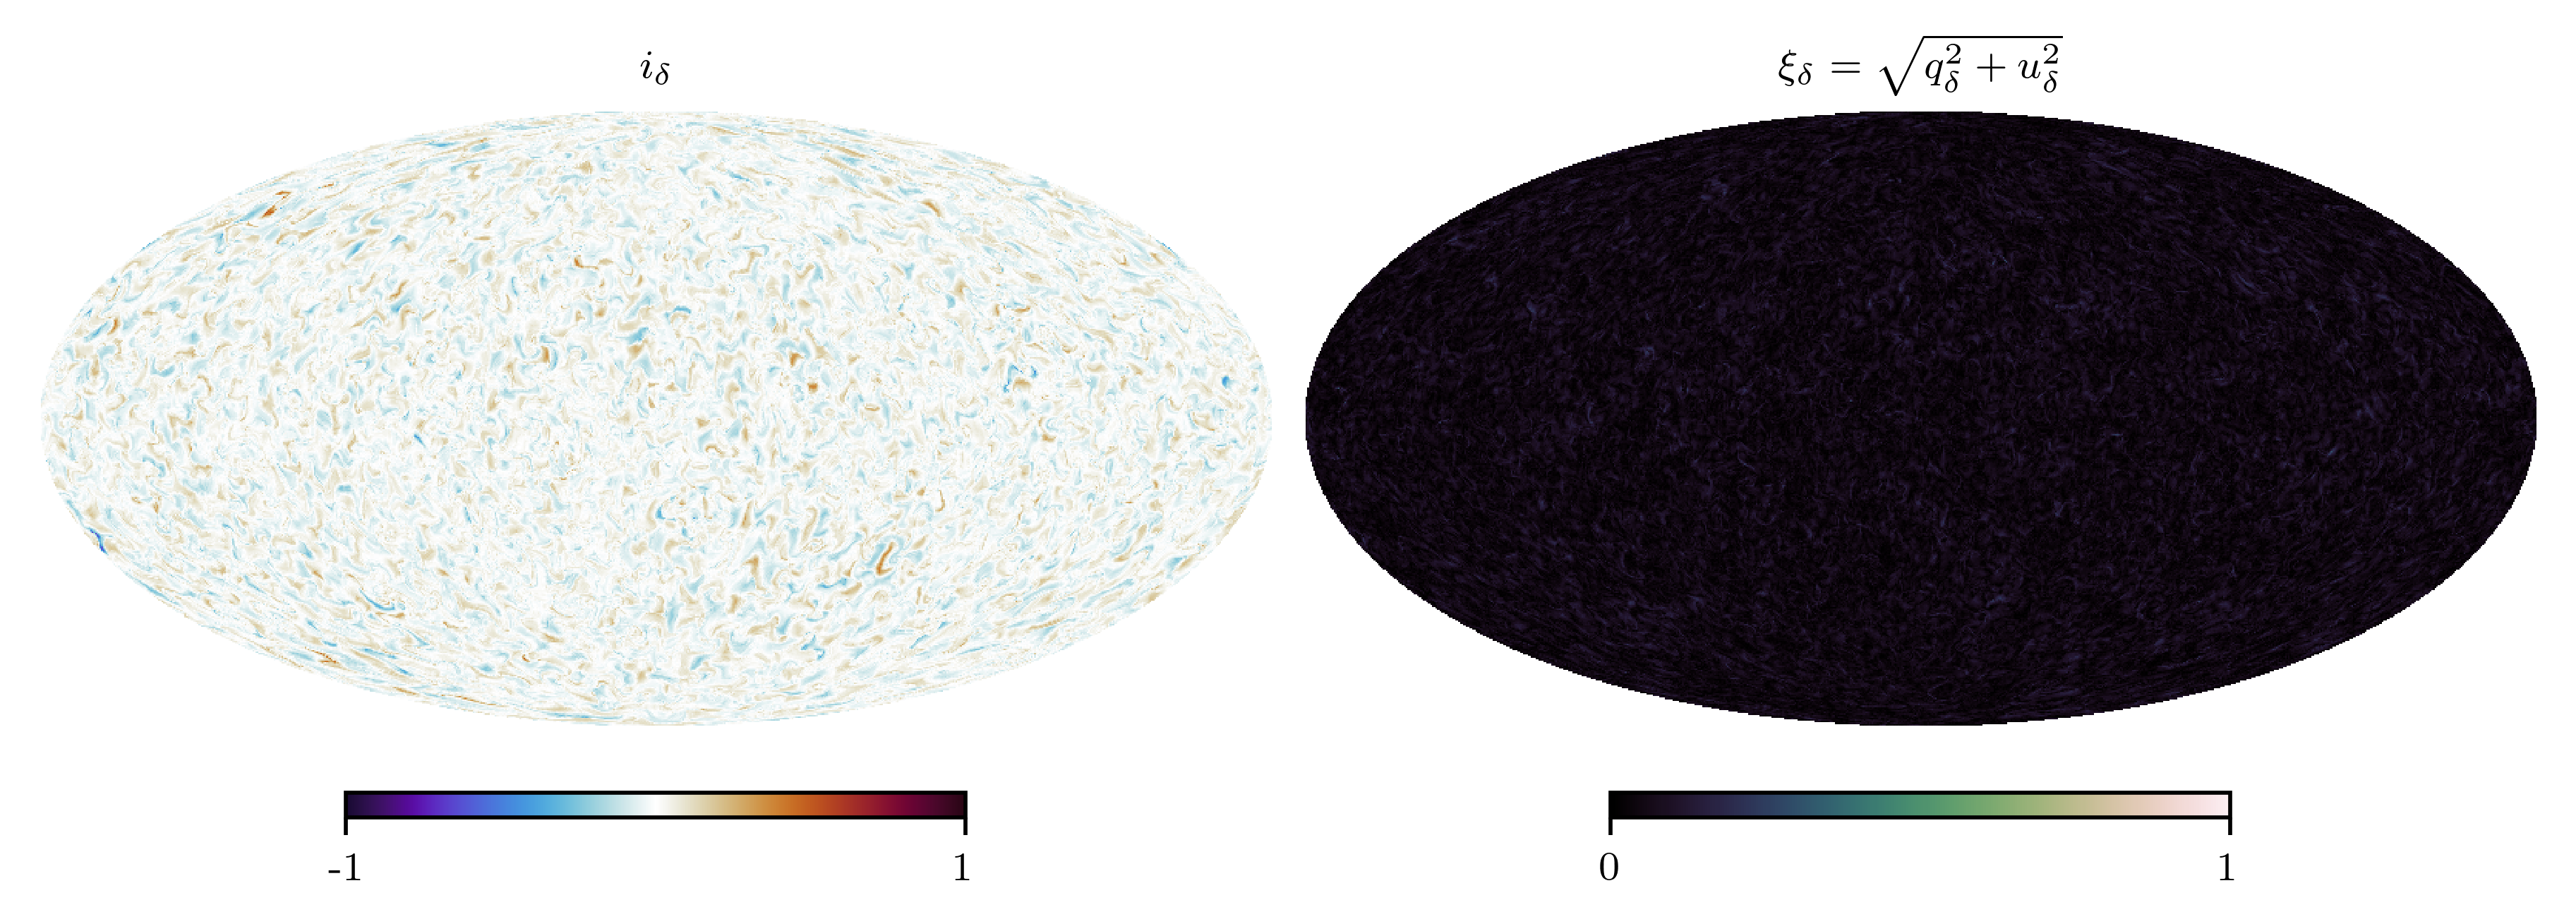

In [3]:
fig = plt.figure(figsize=(7., 3.5), dpi=512)

fusion_cmap = cmr.fusion_r
fusion_cmap.set_under('w')

pol_cmap = sns.cubehelix_palette(start=0.5, rot=-0.95, dark=0.0, light=0.95, as_cmap=True, reverse=True)
pol_cmap.set_under('w')

hp.mollview(i_delta, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 2, 1), title='')
ax = plt.gca()
ax.set_title(r'$i_\delta$', fontsize=8.)
hp.mollview(np.sqrt(q_delta**2 + u_delta**2), cmap=pol_cmap, min=0., max=1., fig=fig, sub=(1, 2, 2), title='')
ax = plt.gca()
ax.set_title(r'$\xi_\delta = \sqrt{q_\delta^2 + u_\delta^2}$', fontsize=8.)


Text(0.5, 1.0, '$b_\\delta$')

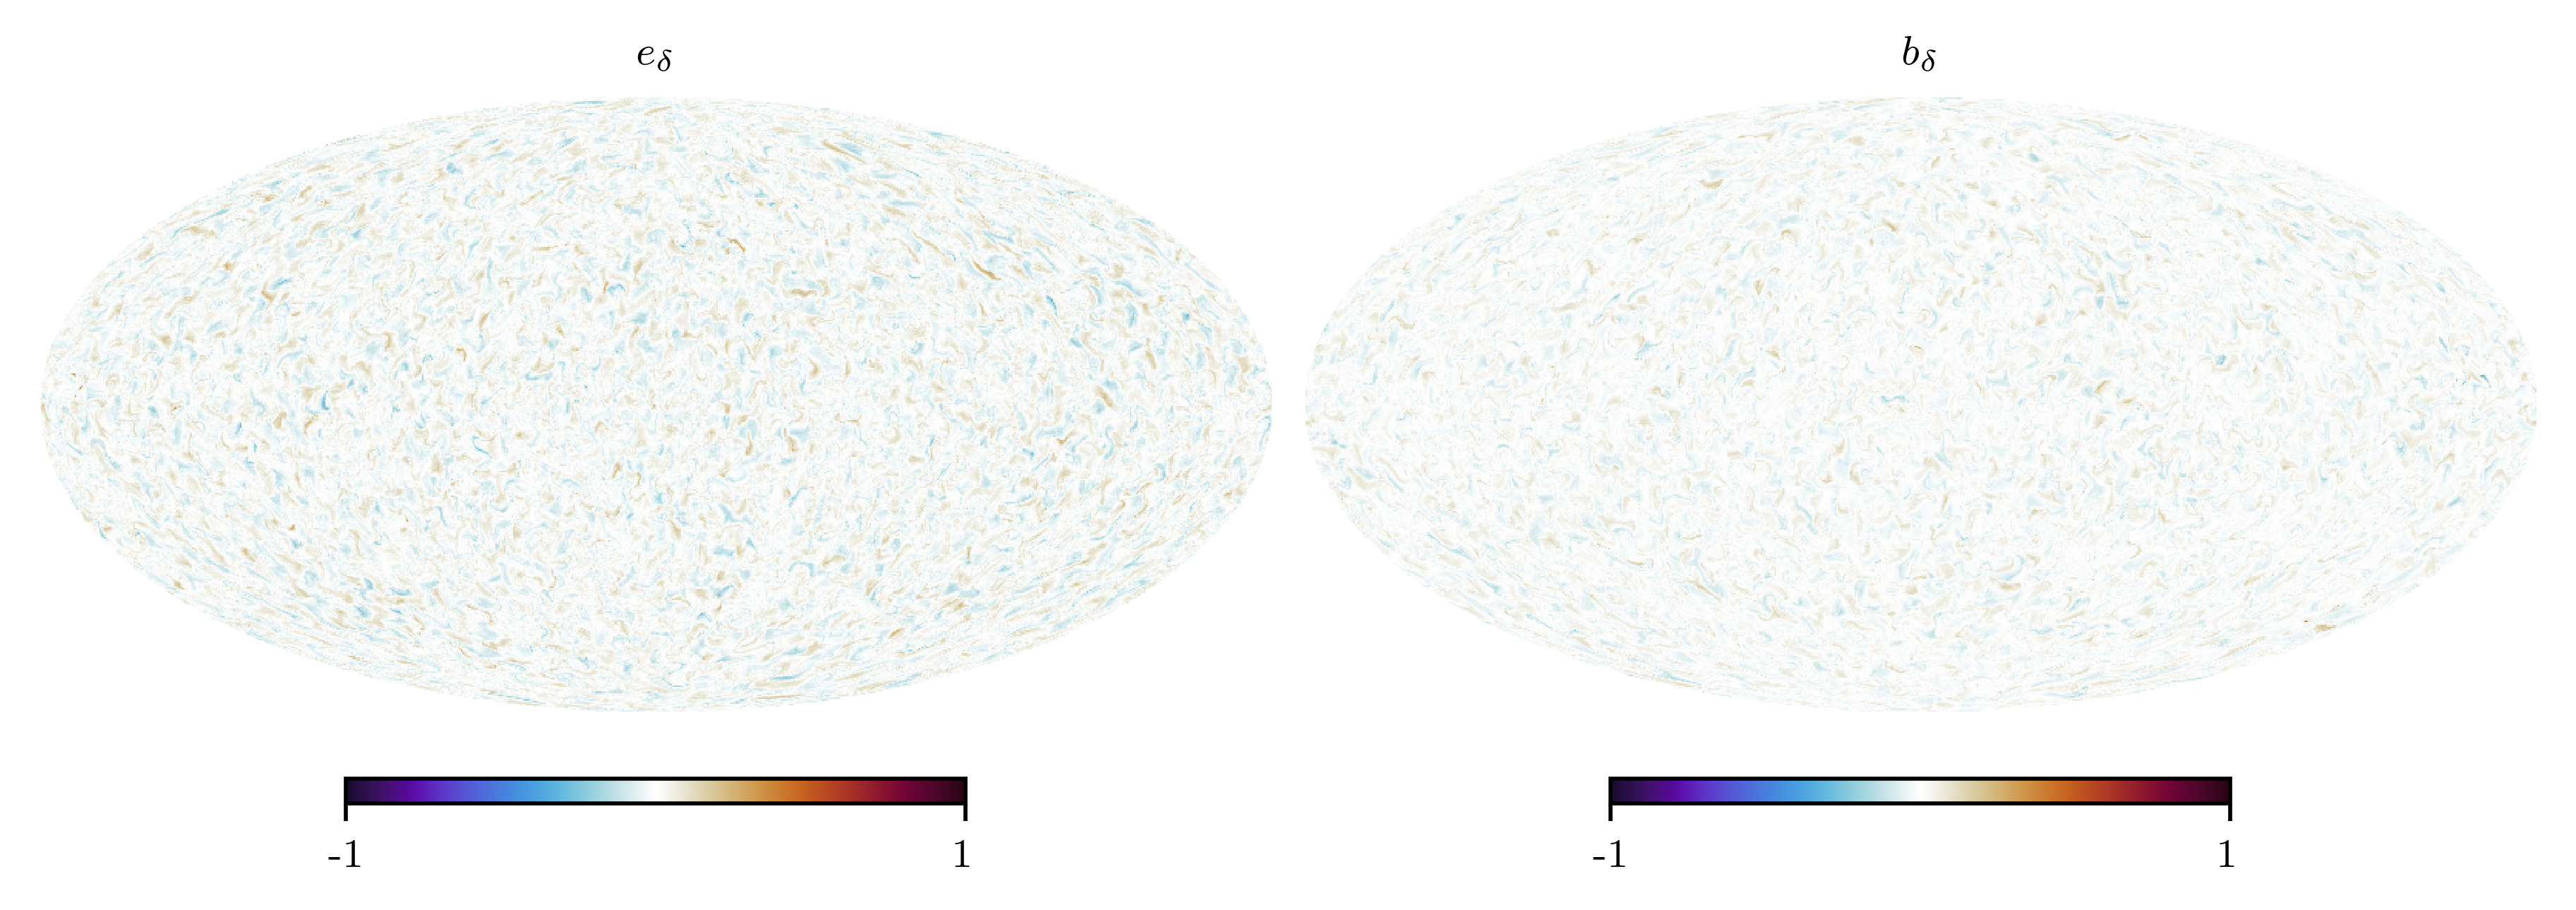

In [ ]:
fig = plt.figure(figsize=(7., 3.5), dpi=512)

fusion_cmap = cmr.fusion_r
fusion_cmap.set_under('w')

hp.mollview(e_delta, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 2, 1), title='')
ax = plt.gca()
ax.set_title(r'$e_\delta$', fontsize=8.)
hp.mollview(b_delta, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 2, 2), title='')
ax = plt.gca()
ax.set_title(r'$b_\delta$', fontsize=8.)


In [5]:
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta, q_delta, u_delta, NSIDE)

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:676: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:677: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:676: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:677: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:621: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:577: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


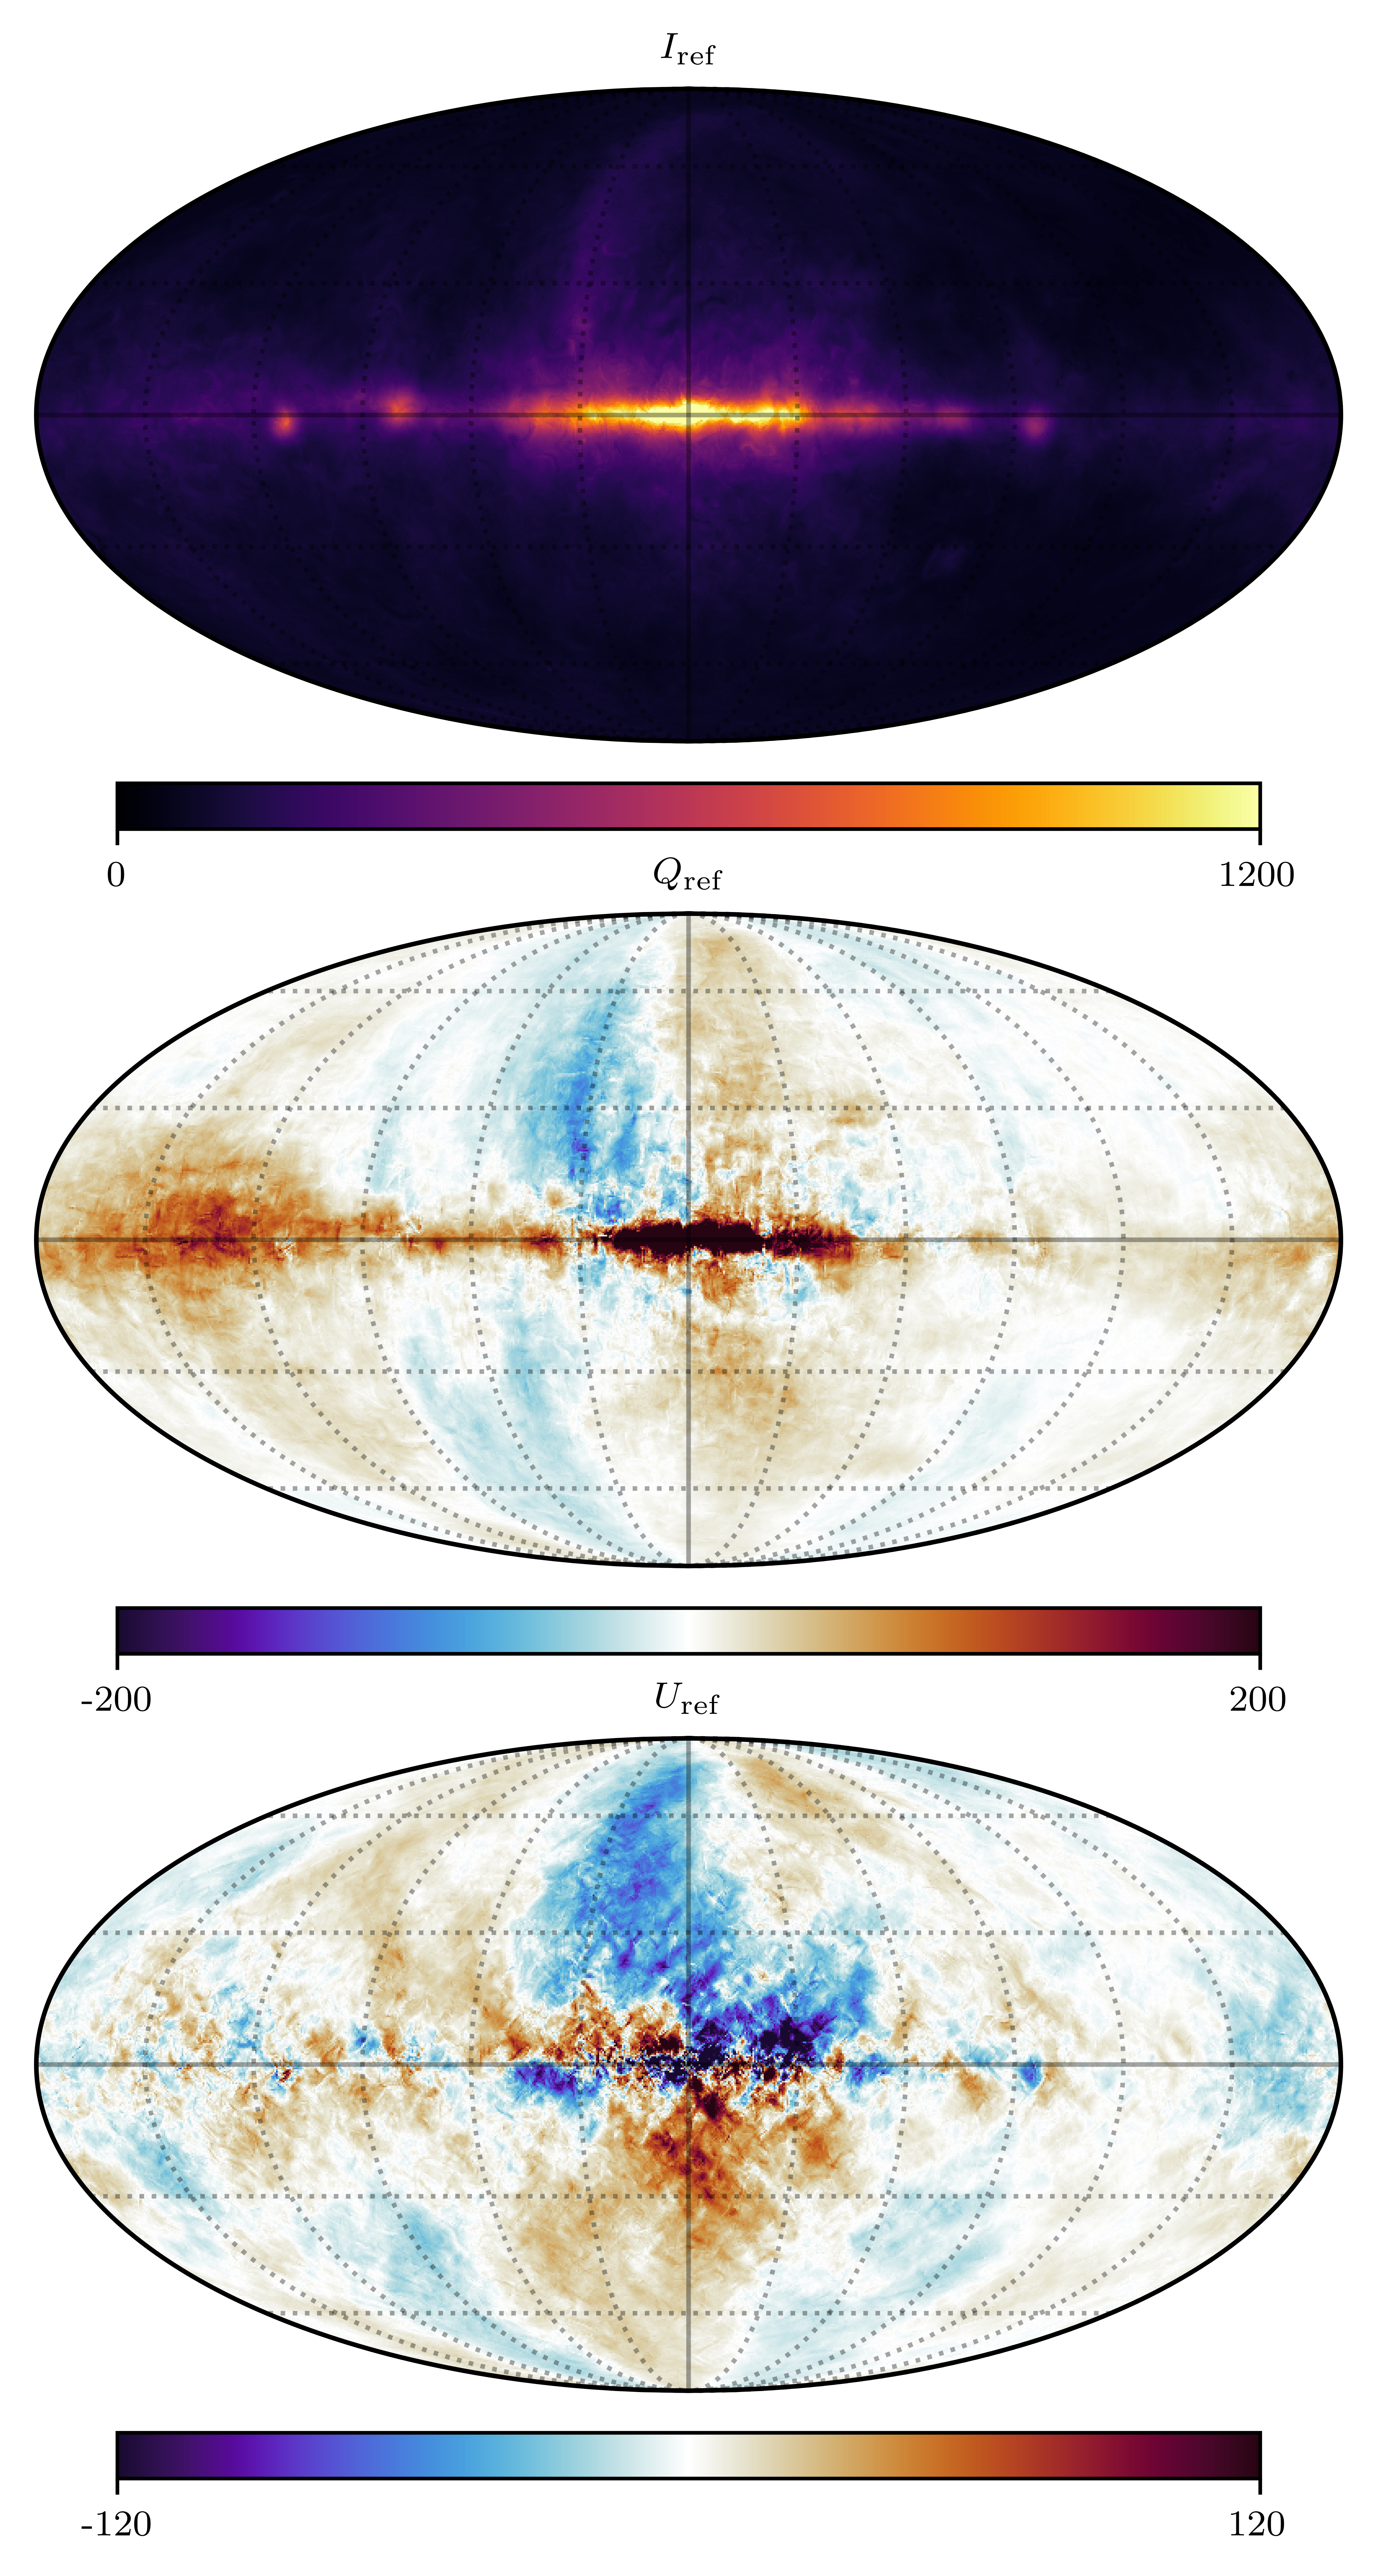

In [14]:

fig = plt.figure(figsize=(3.5*2., 2.5*3.), dpi=1024)

cminI, cmaxI = 0., 1200.
cminQ, cmaxQ = -200., 200.
cminU, cmaxU = -120., 120.

cmapI = sns.color_palette('inferno', as_cmap=True)
cmapI.set_under('w')
hp.mollview(I_ref, cmap=cmapI, title=r'', fig=fig, sub=(3, 1, 1), min=cminI, max=cmaxI, bgcolor='white')
ax = plt.gca()
ax.set_title(r'$I_\mathrm{ref}$', fontsize=8.)

hp.mollview(Q_ref, cmap=fusion_cmap, title=r'', fig=fig, sub=(3, 1, 2), min=cminQ, max=cmaxQ, bgcolor='white')
ax = plt.gca()
ax.set_title(r'$Q_\mathrm{ref}$', fontsize=8.)

hp.mollview(U_ref, cmap=fusion_cmap, title=r'', fig=fig, sub=(3, 1, 3), min=cminU, max=cmaxU, bgcolor='white')
ax = plt.gca()
ax.set_title(r'$U_\mathrm{ref}$', fontsize=8.)
hp.graticule(alpha=0.35, linewidth=0.1)